# STAT 8330 Data Generation Function Bank

This notebook is a copy/paste library for quickly creating simulated data on an exam. It is self-contained: all generators, notes, and example plots are in this file.

Use this when an exam prompt says to “demonstrate on simulated data,” “conduct a simulation study,” “compare methods under several scenarios,” or “generate sample data.”

## Quick Chooser

| Exam need | Use this generator | Why it is useful |
|---|---|---|
| Simple numeric prediction | `make_linear_regression_data` | Baseline linear regression and train/test MSE |
| Curved regression | `make_polynomial_regression_data` | Polynomial degree and overfitting |
| Smooth nonlinear regression | `make_sine_regression_data` | Splines, kernel smoothers, LOESS/LOWESS |
| Sharp change in trend | `make_piecewise_regression_data` | Shows where global polynomials can struggle |
| Nonconstant variance | `make_heteroskedastic_regression_data` | Residual patterns and model-assumption discussion |
| Lasso simulation | `make_sparse_lasso_data` | Many predictors, few true signals |
| Correlated predictors | `make_correlated_regression_data` | Multicollinearity, PCA, regularization |
| Linear classification boundary | `make_gaussian_classification_data` | Logistic regression, LDA, linear SVM |
| Nonlinear classification boundary | `make_moons_classification_data` | KNN, trees, random forests, SVM with RBF kernel |
| Circular nonlinear boundary | `make_circles_classification_data` | Kernel SVM and nonlinear classifiers |
| Imbalanced classes | `make_imbalanced_classification_data` | Confusion matrix, recall, specificity, precision |
| Max-margin demonstration | `make_linearly_separable_data` | Hard-margin/random max-margin classifier |
| K-means / hierarchical clustering | `make_cluster_blob_data` | Clean cluster recovery |
| Clustering failure example | `make_anisotropic_cluster_data` | Non-spherical clusters where k-means can fail |
| PCA example | `make_pca_factor_data` | Correlated variables and explained variance |
| Bootstrap/permutation | `make_two_group_mean_data` | Difference in means, bootstrap CI, permutation test |
| Discrete simulation | `make_exam_slot_schedule_data` | Final-exam slot simulation style problems |

General exam rule: choose the simplest generator that highlights the concept you need to demonstrate.

## Imports

These are common packages already used in the review notebooks. The functions below mostly return either `(X, y)` arrays or a `pandas.DataFrame` when a data-frame format is convenient.

In [1]:
import numpy as np  # Import arrays, linear algebra, and random-number tools.
import pandas as pd  # Import DataFrame tools for table-shaped simulated data.
import matplotlib.pyplot as plt  # Import plotting tools for quick exam figures.
from IPython.display import display  # Import display for clean DataFrame output in notebooks.
from sklearn.datasets import make_blobs, make_classification, make_circles, make_moons  # Import sklearn simulation helpers.
from sklearn.preprocessing import StandardScaler  # Import standardization for PCA/clustering examples.
RANDOM_SEED = 123  # Store one default random seed for reproducibility.
np.random.seed(RANDOM_SEED)  # Fix legacy NumPy randomness used by some library calls.
plt.style.use('default')  # Use a predictable plotting style.


## Copy/Paste Generator Functions

The functions are intentionally explicit and lightly parameterized. On an exam, copy the function you need and change only `n`, `noise`, `random_state`, or the scenario-specific parameters.

In [2]:
def make_linear_regression_data(n=120, slope=3.0, intercept=2.0, noise=1.0, random_state=123):  # Generate a simple straight-line regression data set.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = rng.uniform(-3.0, 3.0, size=n)  # Draw one numeric predictor over a moderate range.
    signal = intercept + slope * x  # Compute the true linear mean response.
    y = signal + rng.normal(0.0, noise, size=n)  # Add Gaussian noise to create observed responses.
    X = x.reshape(-1, 1)  # Reshape x into a two-dimensional sklearn design matrix.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})  # Store a data-frame version for plotting or LOESS-style functions.
    return X, y, dat  # Return sklearn arrays plus the data frame.


def make_polynomial_regression_data(n=140, noise=2.0, random_state=123):  # Generate a curved polynomial regression data set.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = rng.uniform(-2.5, 2.5, size=n)  # Draw a single predictor on a centered interval.
    signal = 1.0 - 2.0 * x + 0.8 * x**2 + 0.7 * x**3  # Define a cubic mean curve.
    y = signal + rng.normal(0.0, noise, size=n)  # Add independent Gaussian noise.
    X = x.reshape(-1, 1)  # Reshape x for sklearn estimators.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})  # Store the simulated data and true signal.
    return X, y, dat  # Return sklearn arrays plus the data frame.


def make_sine_regression_data(n=120, noise=0.35, random_state=123):  # Generate a smooth nonlinear regression data set.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = np.sort(rng.uniform(0.0, 3.0, size=n))  # Draw and sort x values for clean smoother plots.
    signal = 4.0 + np.sin(3.0 * x)  # Define a smooth nonlinear mean function.
    y = signal + rng.normal(0.0, noise, size=n)  # Add Gaussian noise around the smooth signal.
    X = x.reshape(-1, 1)  # Reshape x into a sklearn design matrix.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})  # Store the observed and true curves.
    return X, y, dat  # Return sklearn arrays plus the data frame.


def make_piecewise_regression_data(n=140, noise=0.45, random_state=123):  # Generate a regression data set with a change in slope.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = np.sort(rng.uniform(-3.0, 3.0, size=n))  # Draw sorted predictor values.
    signal = np.where(x < 0.0, 1.0 + 0.4 * x, 1.0 + 2.0 * x)  # Use one slope before zero and a steeper slope after zero.
    y = signal + rng.normal(0.0, noise, size=n)  # Add Gaussian noise to the piecewise signal.
    X = x.reshape(-1, 1)  # Reshape x for sklearn.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})  # Store the data for plotting.
    return X, y, dat  # Return sklearn arrays plus the data frame.


def make_heteroskedastic_regression_data(n=140, random_state=123):  # Generate regression data with nonconstant error variance.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = np.sort(rng.uniform(0.0, 4.0, size=n))  # Draw sorted predictor values.
    noise_sd = 0.20 + 0.35 * x  # Make the error standard deviation increase with x.
    signal = 1.0 + 1.5 * x  # Define a simple linear mean.
    y = signal + rng.normal(0.0, noise_sd, size=n)  # Add noise with x-dependent spread.
    X = x.reshape(-1, 1)  # Reshape x for sklearn.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal, 'noise_sd': noise_sd})  # Store data and variance pattern.
    return X, y, dat  # Return sklearn arrays plus the data frame.


def make_sparse_lasso_data(n=120, p=20, n_active=4, noise=1.0, random_state=123):  # Generate many-predictor regression data for lasso.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    X = rng.normal(0.0, 1.0, size=(n, p))  # Draw standardized-looking predictors.
    beta = np.zeros(p)  # Start with all coefficients equal to zero.
    active_values = np.linspace(3.0, 1.0, n_active) * np.where(np.arange(n_active) % 2 == 0, 1.0, -1.0)  # Create alternating positive and negative signals.
    beta[:n_active] = active_values  # Put the nonzero signals in the first n_active predictors.
    y = X @ beta + rng.normal(0.0, noise, size=n)  # Generate response from sparse linear signal plus noise.
    columns = [f'x{j + 1}' for j in range(p)]  # Create readable predictor names.
    dat = pd.DataFrame(X, columns=columns)  # Store predictors in a DataFrame.
    dat['y'] = y  # Add the response column to the DataFrame.
    return X, y, beta, dat  # Return arrays, true coefficients, and data frame.


def make_correlated_regression_data(n=140, p=6, rho=0.75, noise=1.0, random_state=123):  # Generate regression data with correlated predictors.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    covariance = rho ** np.abs(np.subtract.outer(np.arange(p), np.arange(p)))  # Build an AR(1)-style covariance matrix.
    X = rng.multivariate_normal(np.zeros(p), covariance, size=n)  # Draw correlated predictors.
    beta = np.array([2.0, -1.5, 1.0] + [0.0] * (p - 3))  # Define a few true nonzero coefficients.
    y = X @ beta + rng.normal(0.0, noise, size=n)  # Generate response from correlated predictors plus noise.
    dat = pd.DataFrame(X, columns=[f'x{j + 1}' for j in range(p)])  # Store predictors in named columns.
    dat['y'] = y  # Add the response column.
    return X, y, beta, dat  # Return arrays, true coefficients, and data frame.


def make_gaussian_classification_data(n=180, class_sep=1.4, random_state=123):  # Generate a roughly linear two-class problem.
    X, y = make_classification(  # Use sklearn's classification simulator.
        n_samples=n,  # Set the number of observations.
        n_features=2,  # Use two predictors so the data can be plotted.
        n_informative=2,  # Make both predictors useful.
        n_redundant=0,  # Avoid redundant columns.
        n_clusters_per_class=1,  # Use one cluster per class for a clean boundary.
        class_sep=class_sep,  # Control how separated the classes are.
        random_state=random_state,  # Fix the simulation seed.
    )  # Finish the simulator call.
    dat = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'class': y})  # Store data in a DataFrame for plotting.
    return X, y, dat  # Return arrays and the data frame.


def make_moons_classification_data(n=200, noise=0.25, random_state=123):  # Generate a nonlinear two-moon classification problem.
    X, y = make_moons(n_samples=n, noise=noise, random_state=random_state)  # Simulate two interlocking classes.
    dat = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'class': y})  # Store the data in a DataFrame.
    return X, y, dat  # Return arrays and the data frame.


def make_circles_classification_data(n=220, noise=0.10, factor=0.45, random_state=123):  # Generate a circular nonlinear classification problem.
    X, y = make_circles(n_samples=n, noise=noise, factor=factor, random_state=random_state)  # Simulate inner and outer circle classes.
    dat = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'class': y})  # Store the data in a DataFrame.
    return X, y, dat  # Return arrays and the data frame.


def make_imbalanced_classification_data(n=220, weight_majority=0.85, class_sep=1.2, random_state=123):  # Generate an imbalanced binary classification problem.
    X, y = make_classification(  # Use sklearn's flexible classification simulator.
        n_samples=n,  # Set the total number of observations.
        n_features=2,  # Use two predictors for plotting.
        n_informative=2,  # Make both predictors informative.
        n_redundant=0,  # Avoid redundant predictors.
        n_clusters_per_class=1,  # Use one cluster per class.
        weights=[weight_majority, 1.0 - weight_majority],  # Control the class imbalance.
        class_sep=class_sep,  # Control class separation.
        random_state=random_state,  # Fix the simulation seed.
    )  # Finish the simulator call.
    dat = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'class': y})  # Store data in a DataFrame.
    return X, y, dat  # Return arrays and the data frame.


def make_linearly_separable_data(n_per_class=40, gap=1.7, scale=0.35, random_state=123):  # Generate data for max-margin classification.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    class0 = rng.normal(loc=[-gap, -gap], scale=scale, size=(n_per_class, 2))  # Generate class 0 around the lower-left center.
    class1 = rng.normal(loc=[gap, gap], scale=scale, size=(n_per_class, 2))  # Generate class 1 around the upper-right center.
    X = np.vstack([class0, class1])  # Stack both classes into one predictor matrix.
    y = np.array([0] * n_per_class + [1] * n_per_class)  # Create binary labels.
    dat = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'class': y})  # Store data in a DataFrame.
    return X, y, dat  # Return arrays and the data frame.


def make_cluster_blob_data(n=180, centers=3, cluster_std=0.75, random_state=123):  # Generate clean blob-shaped clusters.
    X, labels = make_blobs(n_samples=n, centers=centers, cluster_std=cluster_std, random_state=random_state)  # Simulate cluster data.
    dat = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'true_cluster': labels})  # Store data and true labels.
    return X, labels, dat  # Return arrays and the data frame.


def make_anisotropic_cluster_data(n=240, centers=3, cluster_std=0.75, random_state=123):  # Generate stretched non-spherical clusters.
    X, labels = make_blobs(n_samples=n, centers=centers, cluster_std=cluster_std, random_state=random_state)  # Start from spherical blob clusters.
    transform = np.array([[0.65, -0.75], [1.20, 0.45]])  # Define a linear transformation that stretches and rotates clusters.
    X_aniso = X @ transform  # Apply the transformation to create anisotropic clusters.
    dat = pd.DataFrame({'x1': X_aniso[:, 0], 'x2': X_aniso[:, 1], 'true_cluster': labels})  # Store transformed data and true labels.
    return X_aniso, labels, dat  # Return arrays and the data frame.


def make_pca_factor_data(n=180, n_features=6, n_factors=2, noise=0.35, random_state=123):  # Generate correlated variables from low-dimensional latent factors.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    factors = rng.normal(0.0, 1.0, size=(n, n_factors))  # Simulate latent factors.
    loadings = rng.normal(0.0, 1.0, size=(n_factors, n_features))  # Simulate factor loadings for observed variables.
    X = factors @ loadings + rng.normal(0.0, noise, size=(n, n_features))  # Generate observed correlated variables.
    dat = pd.DataFrame(X, columns=[f'x{j + 1}' for j in range(n_features)])  # Store variables in a DataFrame.
    return X, factors, loadings, dat  # Return observed data, latent factors, loadings, and data frame.


def make_two_group_mean_data(n1=35, n2=35, mean1=1.0, mean2=0.35, sd=1.0, random_state=123):  # Generate two groups for bootstrap or permutation tests.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    group1 = rng.normal(mean1, sd, size=n1)  # Simulate outcomes for group 1.
    group2 = rng.normal(mean2, sd, size=n2)  # Simulate outcomes for group 2.
    dat = pd.DataFrame({'value': np.concatenate([group1, group2]), 'group': ['group1'] * n1 + ['group2'] * n2})  # Store values and labels.
    return group1, group2, dat  # Return arrays and the data frame.


def make_exam_slot_schedule_data(days=None, n_slots=3, n_exams=3, random_state=123):  # Generate one student's exam schedule without replacement.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    if days is None:  # Check whether the caller provided day labels.
        days = ['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']  # Use the old-final-style UGA day labels by default.
    total_slots = len(days) * n_slots  # Compute the total number of exam slots.
    slot_numbers = np.arange(total_slots)  # Create zero-based slot indices.
    sampled_slots = np.sort(rng.choice(slot_numbers, size=n_exams, replace=False))  # Sample unique exam slots and sort them in time order.
    day_index = sampled_slots // n_slots  # Convert slot indices to day indices.
    period_index = sampled_slots % n_slots + 1  # Convert slot indices to within-day period numbers.
    dat = pd.DataFrame({'slot_index': sampled_slots, 'day': [days[i] for i in day_index], 'period': period_index})  # Store the schedule in a DataFrame.
    return dat  # Return the simulated schedule.


## Plotting Helpers

These are small plotting utilities for the examples below. They are not required for the generators, but they make it fast to visualize whether the simulated data match the exam concept.

In [3]:
def plot_regression_dat(dat, ax, title):  # Define a reusable regression plotting helper.
    order = np.argsort(dat['x'].to_numpy())  # Sort by x so the true curve draws correctly.
    ax.scatter(dat['x'], dat['y'], s=22, alpha=0.60, label='observed')  # Plot noisy observations.
    if 'truth' in dat.columns:  # Check whether the true signal is available.
        ax.plot(dat['x'].to_numpy()[order], dat['truth'].to_numpy()[order], color='red', linewidth=2, label='truth')  # Plot the true mean curve.
    ax.set_title(title)  # Add a short subplot title.
    ax.set_xlabel('x')  # Label the predictor axis.
    ax.set_ylabel('y')  # Label the response axis.
    ax.legend(fontsize=8)  # Show the legend using compact font.


def plot_classification_dat(dat, ax, title):  # Define a reusable two-class scatterplot helper.
    ax.scatter(dat['x1'], dat['x2'], c=dat['class'], s=26, alpha=0.75)  # Plot points colored by class label.
    ax.set_title(title)  # Add a short subplot title.
    ax.set_xlabel('x1')  # Label the first predictor axis.
    ax.set_ylabel('x2')  # Label the second predictor axis.


def plot_cluster_dat(dat, label_col, ax, title):  # Define a reusable cluster scatterplot helper.
    ax.scatter(dat['x1'], dat['x2'], c=dat[label_col], s=26, alpha=0.75)  # Plot points colored by cluster label.
    ax.set_title(title)  # Add a short subplot title.
    ax.set_xlabel('x1')  # Label the first coordinate axis.
    ax.set_ylabel('x2')  # Label the second coordinate axis.


## Regression Examples

Use these for numeric-prediction exam questions: train/test MSE, k-fold CV, LOESS span selection, kernel bandwidth selection, polynomial degree, splines, and lasso.

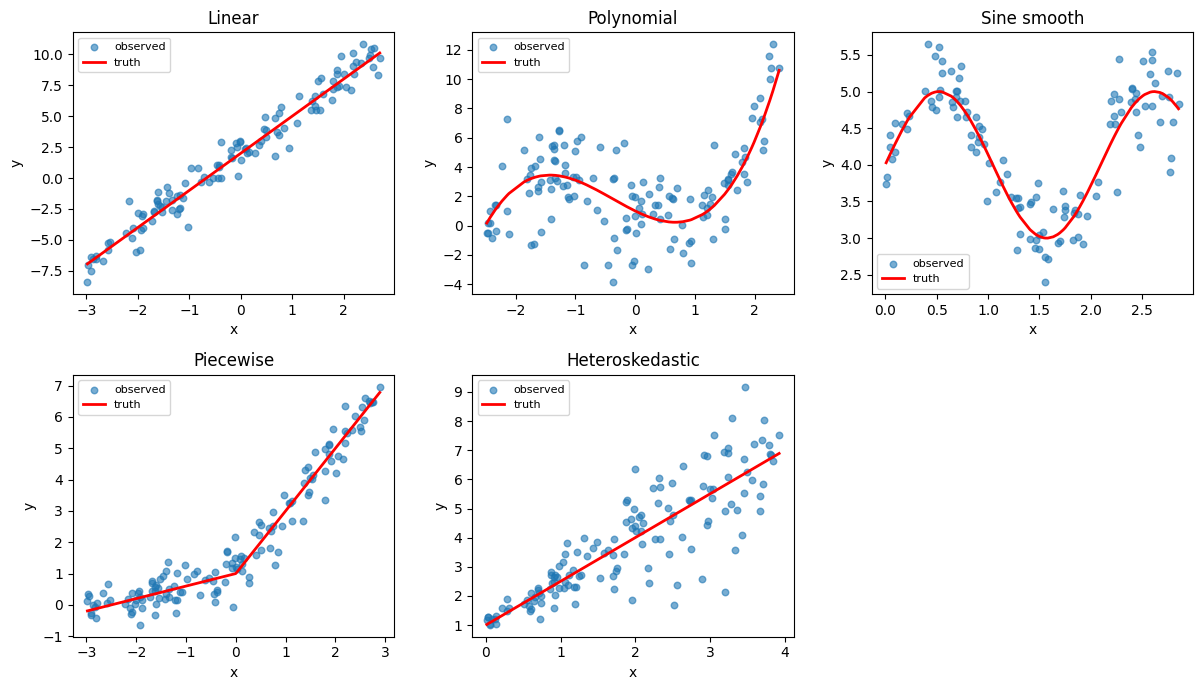

,feature,true_beta
0,x1,3.000000
1,x2,-2.333333
2,x3,1.666667
3,x4,-1.000000
4,x5,0.000000
5,x6,0.000000
6,x7,0.000000
7,x8,0.000000
8,x9,0.000000
9,x10,0.000000


In [4]:
regression_examples = [  # Create a list of named regression examples.
    ('Linear', make_linear_regression_data(random_state=RANDOM_SEED)[2]),  # Add simple linear data.
    ('Polynomial', make_polynomial_regression_data(random_state=RANDOM_SEED)[2]),  # Add polynomial curve data.
    ('Sine smooth', make_sine_regression_data(random_state=RANDOM_SEED)[2]),  # Add smooth nonlinear data.
    ('Piecewise', make_piecewise_regression_data(random_state=RANDOM_SEED)[2]),  # Add piecewise trend data.
    ('Heteroskedastic', make_heteroskedastic_regression_data(random_state=RANDOM_SEED)[2]),  # Add nonconstant variance data.
]  # End the regression example list.
fig, axes = plt.subplots(2, 3, figsize=(12, 7))  # Create a grid of regression plots.
axes_flat = axes.ravel()  # Flatten the axes array for easy looping.
for ax, (title, dat) in zip(axes_flat, regression_examples):  # Loop through regression examples and axes.
    plot_regression_dat(dat, ax, title)  # Draw the example data and true curve.
axes_flat[-1].axis('off')  # Turn off the unused final subplot.
plt.tight_layout()  # Prevent titles and labels from overlapping.
plt.show()  # Render the regression example grid.
X_lasso, y_lasso, beta_lasso, dat_lasso = make_sparse_lasso_data(random_state=RANDOM_SEED)  # Generate lasso-style data.
lasso_summary = pd.DataFrame({'feature': [f'x{j + 1}' for j in range(len(beta_lasso))], 'true_beta': beta_lasso})  # Build a coefficient summary table.
display(lasso_summary.head(10))  # Display the first ten true coefficients for the sparse lasso example.


## Classification Examples

Use these for categorical-response exam questions: accuracy, confusion matrices, LDA/QDA, KNN tuning, tree/forest/boosting comparisons, SVM tuning, and max-margin classifiers.

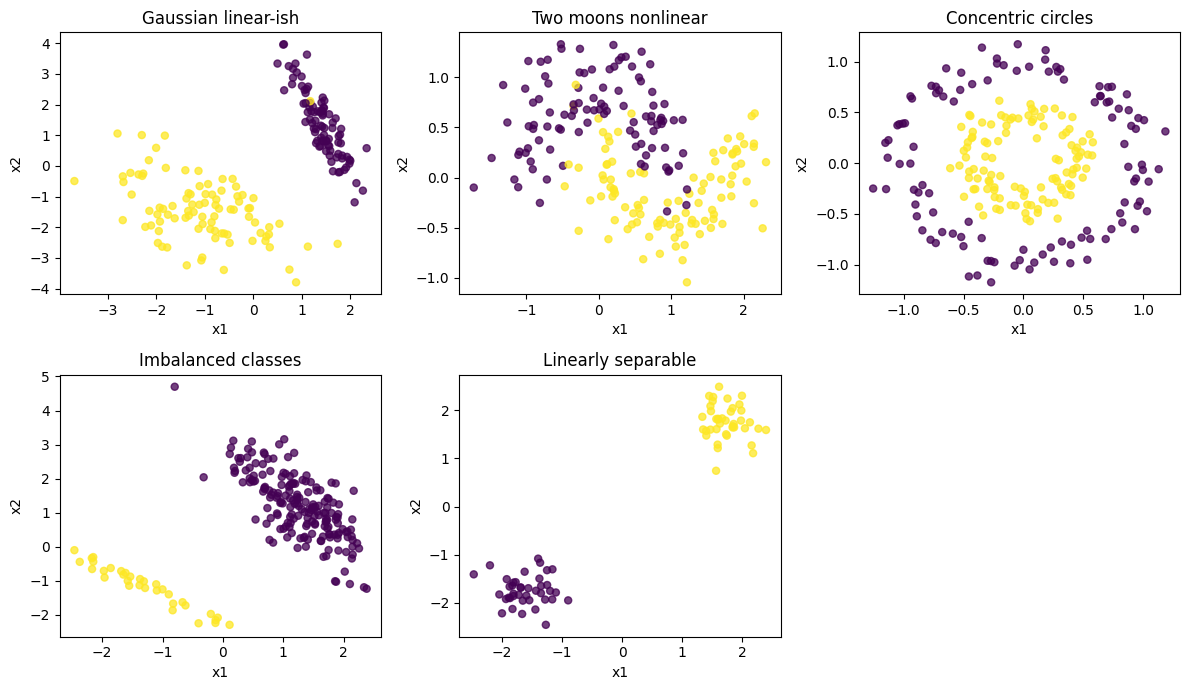

class
0    187
1     33
Name: imbalanced_class_counts, dtype: int64

In [5]:
classification_examples = [  # Create a list of named classification examples.
    ('Gaussian linear-ish', make_gaussian_classification_data(random_state=RANDOM_SEED)[2]),  # Add approximately linear class data.
    ('Two moons nonlinear', make_moons_classification_data(random_state=RANDOM_SEED)[2]),  # Add nonlinear moon-shaped classes.
    ('Concentric circles', make_circles_classification_data(random_state=RANDOM_SEED)[2]),  # Add circular nonlinear classes.
    ('Imbalanced classes', make_imbalanced_classification_data(random_state=RANDOM_SEED)[2]),  # Add imbalanced binary classes.
    ('Linearly separable', make_linearly_separable_data(random_state=RANDOM_SEED)[2]),  # Add max-margin-style separable data.
]  # End the classification example list.
fig, axes = plt.subplots(2, 3, figsize=(12, 7))  # Create a grid of classification plots.
axes_flat = axes.ravel()  # Flatten the axes array for easy looping.
for ax, (title, dat) in zip(axes_flat, classification_examples):  # Loop through classification examples and axes.
    plot_classification_dat(dat, ax, title)  # Draw the class scatterplot.
axes_flat[-1].axis('off')  # Turn off the unused final subplot.
plt.tight_layout()  # Prevent subplot overlap.
plt.show()  # Render the classification example grid.
class_counts = classification_examples[3][1]['class'].value_counts().sort_index()  # Count labels in the imbalanced example.
display(class_counts.rename('imbalanced_class_counts'))  # Display class counts to highlight imbalance.


## Clustering And PCA Examples

Use these for unsupervised-learning questions: PCA standardization, scree plots, k-means elbow plots, hierarchical clustering dendrograms, cluster recovery, and failure modes.

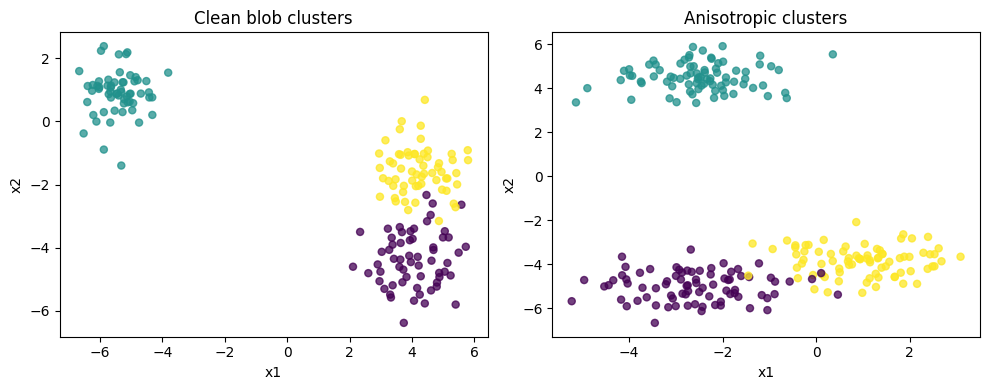

,0,1,2,3,4,5
0,1.00,0.71,-0.70,-0.30,-0.79,0.48
1,0.71,1.00,-0.56,-0.19,-0.66,0.32
2,-0.70,-0.56,1.00,-0.33,0.93,-0.05
3,-0.30,-0.19,-0.33,1.00,-0.23,-0.67
4,-0.79,-0.66,0.93,-0.23,1.00,-0.11
5,0.48,0.32,-0.05,-0.67,-0.11,1.00


In [6]:
X_blob, labels_blob, dat_blob = make_cluster_blob_data(random_state=RANDOM_SEED)  # Generate clean blob clusters.
X_aniso, labels_aniso, dat_aniso = make_anisotropic_cluster_data(random_state=RANDOM_SEED)  # Generate stretched clusters.
X_pca, factors_pca, loadings_pca, dat_pca = make_pca_factor_data(random_state=RANDOM_SEED)  # Generate PCA factor data.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Create a side-by-side cluster plot.
plot_cluster_dat(dat_blob, 'true_cluster', axes[0], 'Clean blob clusters')  # Plot clean cluster data.
plot_cluster_dat(dat_aniso, 'true_cluster', axes[1], 'Anisotropic clusters')  # Plot non-spherical cluster data.
plt.tight_layout()  # Prevent subplot overlap.
plt.show()  # Render the clustering examples.
scaled_pca = StandardScaler().fit_transform(X_pca)  # Standardize PCA example variables.
correlation_matrix = pd.DataFrame(scaled_pca).corr()  # Compute the correlation matrix after standardization.
display(correlation_matrix.round(2))  # Display rounded correlations to show PCA-friendly structure.


## Bootstrap, Permutation, And Discrete Simulation Examples

Use these for simulation/inference prompts: bootstrap confidence intervals, permutation tests, and old-final-style probability simulations.

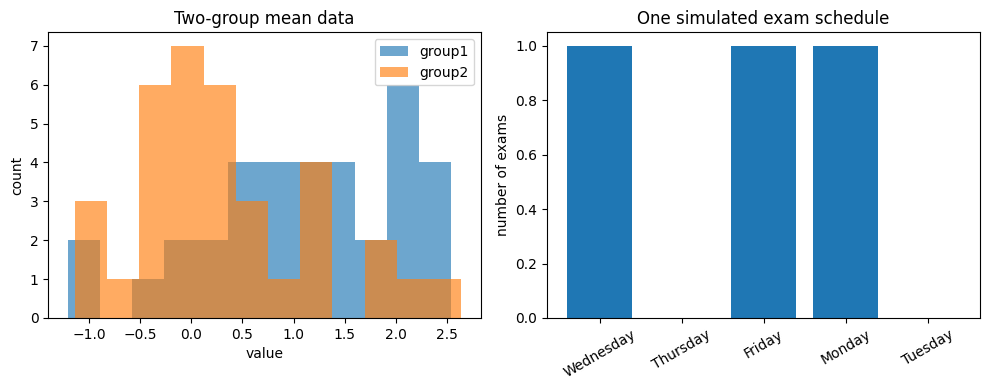

,value,group
0,0.010879,group1
1,0.632213,group1
2,2.287925,group1
3,1.193974,group1
4,1.920231,group1


,slot_index,day,period
0,0,Wednesday,1
1,8,Friday,3
2,9,Monday,1


In [7]:
group1, group2, dat_groups = make_two_group_mean_data(random_state=RANDOM_SEED)  # Generate two groups for inference examples.
schedule_dat = make_exam_slot_schedule_data(random_state=RANDOM_SEED)  # Generate one simulated final-exam schedule.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Create side-by-side plots for inference examples.
axes[0].hist(group1, alpha=0.65, bins=12, label='group1')  # Plot group 1 outcomes.
axes[0].hist(group2, alpha=0.65, bins=12, label='group2')  # Plot group 2 outcomes.
axes[0].set_title('Two-group mean data')  # Title the two-group histogram.
axes[0].set_xlabel('value')  # Label the histogram x-axis.
axes[0].set_ylabel('count')  # Label the histogram y-axis.
axes[0].legend()  # Show group labels.
schedule_counts = schedule_dat['day'].value_counts().reindex(['Wednesday', 'Thursday', 'Friday', 'Monday', 'Tuesday']).fillna(0)  # Count exams by day in the schedule.
axes[1].bar(schedule_counts.index, schedule_counts.values)  # Plot exam counts by day.
axes[1].set_title('One simulated exam schedule')  # Title the schedule plot.
axes[1].set_ylabel('number of exams')  # Label the schedule y-axis.
axes[1].tick_params(axis='x', rotation=30)  # Rotate day labels for readability.
plt.tight_layout()  # Prevent subplot overlap.
plt.show()  # Render the inference and schedule examples.
display(dat_groups.head())  # Display the first rows of the two-group data frame.
display(schedule_dat)  # Display the simulated exam schedule.


## Exam Adaptation Notes

- If the question says **numeric prediction**, start with linear/polynomial/sine regression data and evaluate with MSE.
- If the question says **smoothing parameter**, use `make_sine_regression_data` and tune span or bandwidth by CV/LOOCV.
- If the question says **lasso penalty**, use `make_sparse_lasso_data` and vary `noise`, `p`, or `n_active`.
- If the question says **classification accuracy**, use Gaussian data for linear methods and moons/circles for nonlinear methods.
- If the question says **confusion matrix or class imbalance**, use `make_imbalanced_classification_data`.
- If the question says **max margin**, use `make_linearly_separable_data`.
- If the question says **PCA or clustering**, use blob/factor data and standardize before fitting.
- If the question says **bootstrap or permutation**, use `make_two_group_mean_data`.
- If the question says **probability by simulation**, use a custom generator like `make_exam_slot_schedule_data` and repeat it many times.

The safest exam answer usually names the data-generating scenario, fixes a random seed, repeats enough replicates, and summarizes with a table or plot.